# Quick look at vpo triad

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
conns = pd.read_csv("/Users/ggutierr/Documents/FlyWireData/connections_princeton.csv")
#conns.rename(columns={"root_id": "id"}, inplace=True)
conns

,pre_root_id,post_root_id,neuropil,syn_count,nt_type
0,720575940625363947,720575940623224444,ME_L,12,GABA
1,720575940630432382,720575940618518557,ME_L,67,ACH
2,720575940627314521,720575940626337738,ME_L,10,GABA
3,720575940620280405,720575940620204726,ME_L,15,ACH
4,720575940636942447,720575940613789411,LA_L,1,GLUT
...,...,...,...,...,...
5342441,720575940610739918,720575940617129885,PLP_L,5,ACH
5342442,720575940653332385,720575940623905719,CRE_R,2,ACH
5342443,720575940622485887,720575940631031803,ME_R,9,ACH
5342444,720575940620020534,720575940636489140,SMP_L,2,ACH


In [3]:
types = pd.read_csv("/Users/ggutierr/Documents/FlyWireData/consolidated_cell_types.csv")
types.rename(columns={"root_id": "id"}, inplace=True)
types

,id,primary_type,additional_type(s)
0,720575940596125868,T5c,NaN
1,720575940597856265,Tm16,NaN
2,720575940597944841,Tm7,CB3851
3,720575940598267657,TmY15,NaN
4,720575940599333574,Tm1,NaN
...,...,...,...
137682,720575940661335681,CB0180,NaN
137683,720575940661336193,TmY3,NaN
137684,720575940661337217,KCab-p,NaN
137685,720575940661338497,CB0904,NaN


In [4]:
# get rows where types contains 'vpo'
types[types['primary_type'].str.contains('vpo')]

,id,primary_type,additional_type(s)
38702,720575940619415679,vpoEN,NaN
107459,720575940632385943,vpoEN,NaN
115373,720575940634829168,vpoEN,NaN
116960,720575940635403230,vpoEN,NaN


In [4]:
types[types['additional_type(s)'].str.contains('vpo|pMN', case=False, na=False)]

,id,primary_type,additional_type(s)
13854,720575940612403427,AVLP008,"vpoIN, aSP8_vpoIN"
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN"
20795,720575940614618741,LHAV4c2,aSP8_vpoIN
21333,720575940614752395,AVLP008,"vpoIN, aSP8_vpoIN"
22854,720575940615200059,LHAV4c2,"vpoIN, aSP8_vpoIN"
25164,720575940615894877,CB1385,vpoIN
36406,720575940618812888,CB1385,vpoIN
36555,720575940618851425,AVLP008,"vpoIN, aSP8_vpoIN"
38952,720575940619486891,DNp13,pMN1/DNp13
59306,720575940623256202,AVLP008,"vpoIN, aSP8_vpoIN"


In [23]:
# get all the vpo types 
vpo_neurons = types[types['additional_type(s)'].str.contains('vpo', case=False, na=False)|types['primary_type'].str.contains('vpo',na=False)]
vpo_neurons

,id,primary_type,additional_type(s)
13854,720575940612403427,AVLP008,"vpoIN, aSP8_vpoIN"
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN"
20795,720575940614618741,LHAV4c2,aSP8_vpoIN
21333,720575940614752395,AVLP008,"vpoIN, aSP8_vpoIN"
22854,720575940615200059,LHAV4c2,"vpoIN, aSP8_vpoIN"
25164,720575940615894877,CB1385,vpoIN
36406,720575940618812888,CB1385,vpoIN
36555,720575940618851425,AVLP008,"vpoIN, aSP8_vpoIN"
38702,720575940619415679,vpoEN,NaN
59306,720575940623256202,AVLP008,"vpoIN, aSP8_vpoIN"


In [24]:
# make a new column to neaten up the names
vpo_neurons['cell_type'] = np.where(vpo_neurons['primary_type'].str.contains('vpo', case=False, na=False), vpo_neurons['primary_type'], 'Nan')
vpo_neurons

/var/folders/qb/p6dbns6n14n6pl5jy5tkwp78xfrsnf/T/ipykernel_50339/3268935582.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vpo_neurons['cell_type'] = np.where(vpo_neurons['primary_type'].str.contains('vpo', case=False, na=False), vpo_neurons['primary_type'], 'Nan')


,id,primary_type,additional_type(s),cell_type
13854,720575940612403427,AVLP008,"vpoIN, aSP8_vpoIN",Nan
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN",Nan
20795,720575940614618741,LHAV4c2,aSP8_vpoIN,Nan
21333,720575940614752395,AVLP008,"vpoIN, aSP8_vpoIN",Nan
22854,720575940615200059,LHAV4c2,"vpoIN, aSP8_vpoIN",Nan
25164,720575940615894877,CB1385,vpoIN,Nan
36406,720575940618812888,CB1385,vpoIN,Nan
36555,720575940618851425,AVLP008,"vpoIN, aSP8_vpoIN",Nan
38702,720575940619415679,vpoEN,NaN,vpoEN
59306,720575940623256202,AVLP008,"vpoIN, aSP8_vpoIN",Nan


In [25]:
vpo_neurons['cell_type'] = np.where(vpo_neurons['additional_type(s)'].str.contains('vpoDN', na=False), 'vpoDN', vpo_neurons['cell_type'])
vpo_neurons['cell_type'] = np.where(vpo_neurons['additional_type(s)'].str.contains('vpoIN', na=False), 'vpoIN', vpo_neurons['cell_type'])
vpo_neurons

/var/folders/qb/p6dbns6n14n6pl5jy5tkwp78xfrsnf/T/ipykernel_50339/2865508171.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vpo_neurons['cell_type'] = np.where(vpo_neurons['additional_type(s)'].str.contains('vpoDN', na=False), 'vpoDN', vpo_neurons['cell_type'])
/var/folders/qb/p6dbns6n14n6pl5jy5tkwp78xfrsnf/T/ipykernel_50339/2865508171.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vpo_neurons['cell_type'] = np.where(vpo_neurons['additional_type(s)'].str.contains('vpoIN', na=False), 'vpoIN', vpo_ne

,id,primary_type,additional_type(s),cell_type
13854,720575940612403427,AVLP008,"vpoIN, aSP8_vpoIN",vpoIN
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN",vpoDN
20795,720575940614618741,LHAV4c2,aSP8_vpoIN,vpoIN
21333,720575940614752395,AVLP008,"vpoIN, aSP8_vpoIN",vpoIN
22854,720575940615200059,LHAV4c2,"vpoIN, aSP8_vpoIN",vpoIN
25164,720575940615894877,CB1385,vpoIN,vpoIN
36406,720575940618812888,CB1385,vpoIN,vpoIN
36555,720575940618851425,AVLP008,"vpoIN, aSP8_vpoIN",vpoIN
38702,720575940619415679,vpoEN,NaN,vpoEN
59306,720575940623256202,AVLP008,"vpoIN, aSP8_vpoIN",vpoIN


In [ ]:
# grab connections between vpo neurons
vpo_conns = conns[conns['pre_root_id'].isin(vpo_neurons['id']) & conns['post_root_id'].isin(vpo_neurons['id'])]
vpo_conns

,pre_root_id,post_root_id,neuropil,syn_count,nt_type
213932,720575940634829168,720575940627496829,VES_L,3,ACH
292231,720575940635403230,720575940627496829,VES_L,1,ACH
601724,720575940628256763,720575940619415679,SIP_R,5,GABA
621368,720575940619415679,720575940613170498,LAL_R,2,ACH
845664,720575940615894877,720575940627496829,SCL_L,6,GABA
...,...,...,...,...,...
4771451,720575940627718394,720575940627496829,ICL_L,2,GABA
4836380,720575940632385943,720575940628542807,AVLP_R,1,ACH
4860576,720575940636705502,720575940613170498,SCL_R,2,GABA
4970055,720575940628542807,720575940613170498,SIP_R,26,GABA


In [29]:
# groupby to eliminate duplicate pairs
vpo_conns = vpo_conns[['pre_root_id', 'post_root_id', 'syn_count']].groupby(['pre_root_id', 'post_root_id']).sum().reset_index()
vpo_conns

,pre_root_id,post_root_id,syn_count
0,720575940612403427,720575940613170498,51
1,720575940614752395,720575940613170498,61
2,720575940615200059,720575940627496829,11
3,720575940615894877,720575940627496829,14
4,720575940618812888,720575940613170498,5
5,720575940618851425,720575940613170498,21
6,720575940619415679,720575940613170498,62
7,720575940619415679,720575940627496829,7
8,720575940623256202,720575940627496829,31
9,720575940627718394,720575940627496829,21


In [30]:
# merge cell_types column onto connections dataframe
vpo_type_conns = vpo_conns.merge(vpo_neurons[['id', 'cell_type']], left_on='pre_root_id', right_on='id').drop(columns=['id']).rename(columns={'cell_type': 'pre_type'})
vpo_type_conns = vpo_type_conns.merge(vpo_neurons[['id', 'cell_type']], left_on='post_root_id', right_on='id').drop(columns=['id']).rename(columns={'cell_type': 'post_type'})
vpo_type_conns

,pre_root_id,post_root_id,syn_count,pre_type,post_type
0,720575940612403427,720575940613170498,51,vpoIN,vpoDN
1,720575940614752395,720575940613170498,61,vpoIN,vpoDN
2,720575940615200059,720575940627496829,11,vpoIN,vpoDN
3,720575940615894877,720575940627496829,14,vpoIN,vpoDN
4,720575940618812888,720575940613170498,5,vpoIN,vpoDN
5,720575940618851425,720575940613170498,21,vpoIN,vpoDN
6,720575940619415679,720575940613170498,62,vpoEN,vpoDN
7,720575940619415679,720575940627496829,7,vpoEN,vpoDN
8,720575940623256202,720575940627496829,31,vpoIN,vpoDN
9,720575940627718394,720575940627496829,21,vpoIN,vpoDN


In [31]:
# groupby cell type and sum the weights
vpo_type_conns = vpo_type_conns[['pre_type', 'post_type', 'syn_count']].groupby(['pre_type', 'post_type']).sum().reset_index()
vpo_type_conns

,pre_type,post_type,syn_count
0,vpoEN,vpoDN,204
1,vpoEN,vpoEN,15
2,vpoEN,vpoIN,18
3,vpoIN,vpoDN,416
4,vpoIN,vpoEN,11


{('vpoEN', 'vpoDN'): Text(0.2784414701106297, 0.29990603767068363, '204'),
 ('vpoEN', 'vpoEN'): Text(-0.44311705977874066, 0.6857722090517321, '15'),
 ('vpoEN', 'vpoIN'): Text(-0.5000000000000006, 0.04298006685518263, '18'),
 ('vpoIN', 'vpoDN'): Text(0.22155852988936975, -0.3428861045258658, '416'),
 ('vpoIN', 'vpoEN'): Text(-0.5000000000000006, 0.04298006685518263, '11')}

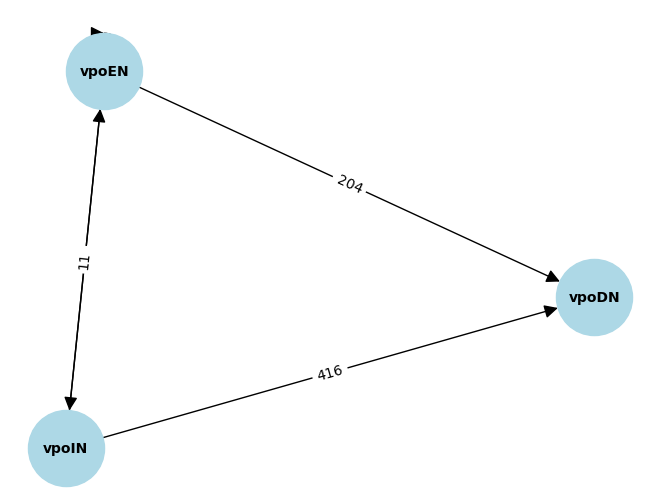

In [33]:
# make a networkx graph
G = nx.from_pandas_edgelist(vpo_type_conns, 'pre_type', 'post_type', ['syn_count'], create_using=nx.DiGraph())
pos = nx.spring_layout(G, seed=42)  # positions for all nodes

# draw the nodes and edges
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold", arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'syn_count')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)



# The sexy effectors
I want to see the network of the neurons we're writing about.

In [6]:
types[types['additional_type(s)'].str.contains('vpo|PMN2', case=False, na=False)]

,id,primary_type,additional_type(s)
13854,720575940612403427,AVLP008,"vpoIN, aSP8_vpoIN"
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN"
20795,720575940614618741,LHAV4c2,aSP8_vpoIN
21333,720575940614752395,AVLP008,"vpoIN, aSP8_vpoIN"
22854,720575940615200059,LHAV4c2,"vpoIN, aSP8_vpoIN"
25164,720575940615894877,CB1385,vpoIN
36406,720575940618812888,CB1385,vpoIN
36555,720575940618851425,AVLP008,"vpoIN, aSP8_vpoIN"
59306,720575940623256202,AVLP008,"vpoIN, aSP8_vpoIN"
82229,720575940627496829,DNp37,"vpoDN, pMN2, pMN2/vpoDN"


In [59]:
types[types['additional_type(s)'].str.contains('vpoDN|PMN', case=False, na=False)]

,id,primary_type,additional_type(s)
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN"
38952,720575940619486891,DNp13,pMN1/DNp13
66102,720575940624463242,CB0666,"hb-953013850, pMN1"
70289,720575940625295339,DNp13,pMN1/DNp13
82229,720575940627496829,DNp37,"vpoDN, pMN2, pMN2/vpoDN"
132102,720575940644300323,CB0666,"hb-953013850, pMN1"


In [9]:
types[types['additional_type(s)'].str.contains('pC2l', case=False, na=False)]

,id,primary_type,additional_type(s)
8957,720575940610373326,CB2375,pC2la
9128,720575940610455781,CL313,pC2la
11119,720575940611401709,AVLP569,pC2lb
30265,720575940617333976,CB2375,pC2la
35032,720575940618475101,AVLP567,pC2lb
38353,720575940619302640,CL313,pC2la
39644,720575940619675712,CL313,pC2la
46008,720575940620931348,CL313,"pC2lc, pC2la"
48852,720575940621431492,CL313,pC2la
61879,720575940623725972,AVLP567,pC2lb


In [60]:
# get all the sexy types 
sexy_neurons = types[types['additional_type(s)'].str.contains('vpoEN|pC2l|pMN', case=False, na=False)|types['primary_type'].str.contains('vpoEN|pC2l|pMN',na=False)]
sexy_neurons

,id,primary_type,additional_type(s)
8940,720575940610359758,pC2la,NaN
8957,720575940610373326,CB2375,pC2la
9128,720575940610455781,CL313,pC2la
11119,720575940611401709,AVLP569,pC2lb
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN"
30265,720575940617333976,CB2375,pC2la
35032,720575940618475101,AVLP567,pC2lb
38353,720575940619302640,CL313,pC2la
38702,720575940619415679,vpoEN,NaN
38952,720575940619486891,DNp13,pMN1/DNp13


In [61]:
# make a new column to neaten up the names
sexy_neurons['cell_type'] = np.where(sexy_neurons['primary_type'].str.contains('vpo|pC2l', case=False, na=False), sexy_neurons['primary_type'], 'Nan')
sexy_neurons['cell_type'] = np.where(sexy_neurons['additional_type(s)'].str.contains('pMN2', na=False), 'pMN2', sexy_neurons['cell_type'])
sexy_neurons['cell_type'] = np.where(sexy_neurons['additional_type(s)'].str.contains('pMN1', na=False), 'pMN1', sexy_neurons['cell_type'])
#sexy_neurons['cell_type'] = np.where(sexy_neurons['additional_type(s)'].str.contains('pC2l', na=False), sexy_neurons['additional_type(s)'], sexy_neurons['cell_type'])
sexy_neurons['cell_type'] = np.where(sexy_neurons['additional_type(s)'].str.contains('pC2l', na=False), 'pC2l', sexy_neurons['cell_type'])
sexy_neurons['cell_type'] = np.where(sexy_neurons['primary_type'].str.contains('pC2l', na=False), 'pC2l', sexy_neurons['cell_type'])
sexy_neurons

/var/folders/qb/p6dbns6n14n6pl5jy5tkwp78xfrsnf/T/ipykernel_2791/3182259565.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sexy_neurons['cell_type'] = np.where(sexy_neurons['primary_type'].str.contains('vpo|pC2l', case=False, na=False), sexy_neurons['primary_type'], 'Nan')
/var/folders/qb/p6dbns6n14n6pl5jy5tkwp78xfrsnf/T/ipykernel_2791/3182259565.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sexy_neurons['cell_type'] = np.where(sexy_neurons['additional_type(s)'].str.contains('pMN2', na=False), 'pM

,id,primary_type,additional_type(s),cell_type
8940,720575940610359758,pC2la,NaN,pC2l
8957,720575940610373326,CB2375,pC2la,pC2l
9128,720575940610455781,CL313,pC2la,pC2l
11119,720575940611401709,AVLP569,pC2lb,pC2l
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN",pMN2
30265,720575940617333976,CB2375,pC2la,pC2l
35032,720575940618475101,AVLP567,pC2lb,pC2l
38353,720575940619302640,CL313,pC2la,pC2l
38702,720575940619415679,vpoEN,NaN,vpoEN
38952,720575940619486891,DNp13,pMN1/DNp13,pMN1


In [62]:
# ids
sexy_neuron_ids = sexy_neurons['id'].tolist()

In [63]:
# get connections between sexy neurons
sexy_conns = conns[conns['pre_root_id'].isin(sexy_neuron_ids) & conns['post_root_id'].isin(sexy_neuron_ids)]
sexy_conns

,pre_root_id,post_root_id,neuropil,syn_count,nt_type
170909,720575940635403230,720575940618475101,SCL_L,1,ACH
172424,720575940638095293,720575940618475101,AVLP_R,15,ACH
174310,720575940636910825,720575940619486891,GOR_L,6,ACH
176046,720575940640176848,720575940625295339,VES_R,13,ACH
176689,720575940630344396,720575940624463242,EPA_R,3,ACH
...,...,...,...,...,...
5316442,720575940638095293,720575940633300148,VES_R,1,ACH
5316767,720575940619415679,720575940638095293,AVLP_R,30,ACH
5326183,720575940620931348,720575940644300323,AVLP_L,4,ACH
5331722,720575940626793831,720575940610455781,ICL_R,1,ACH


In [64]:
# groupby to eliminate duplicate pairs
sexy_conns = sexy_conns[['pre_root_id', 'post_root_id', 'syn_count']].groupby(['pre_root_id', 'post_root_id']).sum().reset_index()
sexy_conns

,pre_root_id,post_root_id,syn_count
0,720575940610359758,720575940644300323,5
1,720575940610373326,720575940624463242,6
2,720575940610373326,720575940644300323,6
3,720575940610455781,720575940619486891,13
4,720575940610455781,720575940625295339,61
...,...,...,...
220,720575940640176848,720575940640992731,5
221,720575940640176848,720575940644300323,8
222,720575940640992731,720575940619486891,67
223,720575940640992731,720575940625295339,36


In [65]:
# make a networkx graph
G = nx.from_pandas_edgelist(sexy_conns, 'pre_root_id', 'post_root_id', ['syn_count'], create_using=nx.DiGraph())

{(720575940610359758,
  720575940644300323): Text(0.9931806592671798, 0.08229730064055402, '5'),
 (720575940610373326,
  720575940624463242): Text(0.912645485977365, 0.4003234255727771, '6'),
 (720575940610373326,
  720575940644300323): Text(0.9660892753756528, 0.2446470311159582, '6'),
 (720575940624463242,
  720575940644300323): Text(0.9329175322731584, 0.320270990300241, '5'),
 (720575940610455781,
  720575940619486891): Text(0.7332110377782096, 0.6749683066288774, '13'),
 (720575940610455781,
  720575940625295339): Text(0.6680443260731754, 0.7256895942766748, '61'),
 (720575940610455781,
  720575940630344396): Text(0.5954179887780735, 0.7649930161892078, '6'),
 (720575940619486891,
  720575940620931348): Text(0.21589795309321197, -0.11683815155601973, '5'),
 (720575940625295339,
  720575940630344396): Text(0.47432179517758233, 0.8764699142077108, '5'),
 (720575940625295339,
  720575940631179807): Text(0.0726264400346868, -0.03930344627716942, '5'),
 (720575940630344396,
  720575940

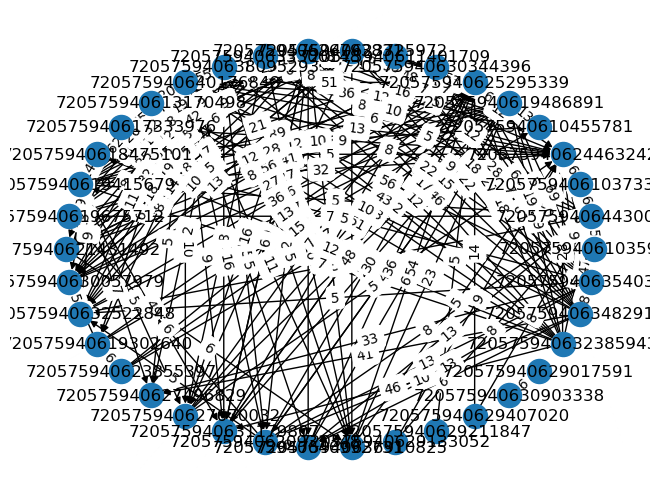

In [66]:
# draw the nodes and edges
#pos = nx.spring_layout(G, seed=42)  # positions for all nodes
pos = nx.circular_layout(G)  # positions for all nodes

nx.draw(G, pos, with_labels=True)
edge_labels = nx.get_edge_attributes(G, 'syn_count')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

Let's see the graph by cell type instead.

In [67]:
# merge cell_types column onto connections dataframe
sexy_type_conns = sexy_conns.merge(sexy_neurons[['id', 'cell_type']], left_on='pre_root_id', right_on='id').drop(columns=['id']).rename(columns={'cell_type': 'pre_type'})
sexy_type_conns = sexy_type_conns.merge(sexy_neurons[['id', 'cell_type']], left_on='post_root_id', right_on='id').drop(columns=['id']).rename(columns={'cell_type': 'post_type'})
sexy_type_conns

,pre_root_id,post_root_id,syn_count,pre_type,post_type
0,720575940610359758,720575940644300323,5,pC2l,pMN1
1,720575940610373326,720575940624463242,6,pC2l,pMN1
2,720575940610373326,720575940644300323,6,pC2l,pMN1
3,720575940610455781,720575940619486891,13,pC2l,pMN1
4,720575940610455781,720575940625295339,61,pC2l,pMN1
...,...,...,...,...,...
220,720575940640176848,720575940640992731,5,pC2l,pC2l
221,720575940640176848,720575940644300323,8,pC2l,pMN1
222,720575940640992731,720575940619486891,67,pC2l,pMN1
223,720575940640992731,720575940625295339,36,pC2l,pMN1


In [68]:
# groupby cell type and sum the weights
sexy_type_conns = sexy_type_conns[['pre_type', 'post_type', 'syn_count']].groupby(['pre_type', 'post_type']).sum().reset_index()
sexy_type_conns

,pre_type,post_type,syn_count
0,pC2l,pC2l,1247
1,pC2l,pMN1,1396
2,pC2l,pMN2,61
3,pC2l,vpoEN,5
4,pMN1,pC2l,15
5,pMN1,pMN1,5
6,pMN2,pMN1,13
7,vpoEN,pC2l,694
8,vpoEN,pMN1,483
9,vpoEN,pMN2,204


{('pC2l', 'pC2l'): Text(0.08293395799736415, -0.10303429810390592, '1247'),
 ('pC2l', 'pMN1'): Text(0.4601258288964624, 0.4392261966361594, '1396'),
 ('pC2l', 'pMN2'): Text(-0.04372176742124589, -0.5515171490519529, '61'),
 ('pC2l', 'vpoEN'): Text(-0.3334701034778524, 0.009256654311887415, '5'),
 ('pMN1', 'pC2l'): Text(0.4601258288964624, 0.4392261966361594, '15'),
 ('pMN1', 'pMN1'): Text(0.8373176997955607, 0.9814866913762248, '5'),
 ('pMN2', 'pMN1'): Text(0.3334701034778524, -0.009256654311887547, '13'),
 ('vpoEN', 'pC2l'): Text(-0.3334701034778524, 0.009256654311887415, '694'),
 ('vpoEN', 'pMN1'): Text(0.043721767421245894, 0.5515171490519528, '483'),
 ('vpoEN', 'pMN2'): Text(-0.4601258288964624, -0.4392261966361596, '204'),
 ('vpoEN', 'vpoEN'): Text(-0.7498741649530689, 0.12154760672768075, '15')}

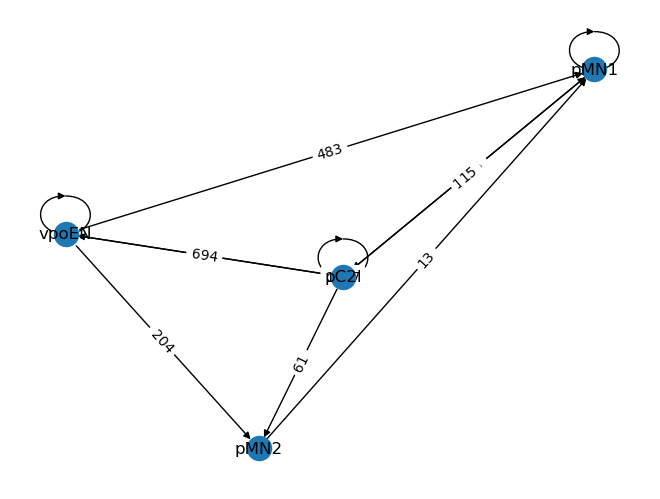

In [69]:
# make a networkx graph
G = nx.from_pandas_edgelist(sexy_type_conns, 'pre_type', 'post_type', ['syn_count'], create_using=nx.DiGraph())
pos = nx.spring_layout(G, seed=42)  # positions for all nodes

# draw the nodes and edges
nx.draw(G, pos, with_labels=True) #, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold", arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'syn_count')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Overlap in inputs to the sexy effectors

In [70]:
# groupby to eliminate duplicate pairs
simple_conns = conns[['pre_root_id', 'post_root_id', 'syn_count']].groupby(['pre_root_id', 'post_root_id']).sum().reset_index()

In [71]:
sexy_neurons

,id,primary_type,additional_type(s),cell_type
8940,720575940610359758,pC2la,NaN,pC2l
8957,720575940610373326,CB2375,pC2la,pC2l
9128,720575940610455781,CL313,pC2la,pC2l
11119,720575940611401709,AVLP569,pC2lb,pC2l
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN",pMN2
30265,720575940617333976,CB2375,pC2la,pC2l
35032,720575940618475101,AVLP567,pC2lb,pC2l
38353,720575940619302640,CL313,pC2la,pC2l
38702,720575940619415679,vpoEN,NaN,vpoEN
38952,720575940619486891,DNp13,pMN1/DNp13,pMN1


In [72]:
# inputs to vpoENs
vpoEN_input_conns = simple_conns[simple_conns['post_root_id'].isin(sexy_neurons[sexy_neurons['cell_type'] == 'vpoEN']['id'].tolist())]
vpoEN_inputs = vpoEN_input_conns['pre_root_id'].tolist()

In [73]:
# inputs to pC2l
pC2l_input_conns = simple_conns[simple_conns['post_root_id'].isin(sexy_neurons[sexy_neurons['cell_type'] == 'pC2l']['id'].tolist())]
pC2l_inputs = pC2l_input_conns['pre_root_id'].tolist()

In [74]:
# inputs to pMN2
pMN2_input_conns = simple_conns[simple_conns['post_root_id'].isin(sexy_neurons[sexy_neurons['cell_type'] == 'pMN2']['id'].tolist())]
pMN2_inputs = pMN2_input_conns['pre_root_id'].tolist()

In [75]:
# inputs to pMN1
pMN1_input_conns = simple_conns[simple_conns['post_root_id'].isin(sexy_neurons[sexy_neurons['cell_type'] == 'pMN1']['id'].tolist())]
pMN1_inputs = pMN1_input_conns['pre_root_id'].tolist()

In [76]:
# sets of inputs for finding overlaps
vpoEN_set = set(vpoEN_inputs)
pC2l_set = set(pC2l_inputs)
pMN1_set = set(pMN1_inputs)
pMN2_set = set(pMN2_inputs)
all_set = vpoEN_set.union(pC2l_set).union(pMN1_set).union(pMN2_set)

In [77]:
# jaccard similarity
def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

In [ ]:
jaccard_similarity(vpoEN_set, pC2l_set), jaccard_similarity(vpoEN_set, pMN2_set), jaccard_similarity(pC2l_set, pMN2_set)

(0.09168081494057725, 0.033210332103321034, 0.09072164948453608)

In [78]:
jaccard_similarity(pMN1_set, pMN2_set), jaccard_similarity(pMN1_set, vpoEN_set), jaccard_similarity(pMN1_set, pC2l_set)

(0.10962566844919786, 0.05168986083499006, 0.28171334431630973)

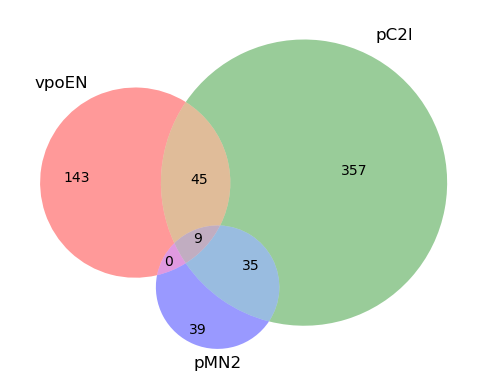

In [55]:
# figure of overlap of inputs to SLP410_R, oviDNb_R, oviDNa_R
from matplotlib_venn import venn3
venn3((vpoEN_set, pC2l_set, pMN2_set), ('vpoEN', 'pC2l', 'pMN2'))
plt.show()

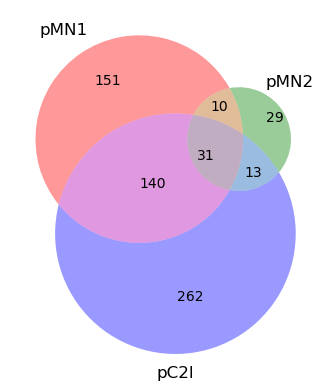

In [80]:
# figure of overlap of inputs to SLP410_R, oviDNb_R, oviDNa_R
from matplotlib_venn import venn3
venn3((pMN1_set, pMN2_set, pC2l_set), ('pMN1', 'pMN2','pC2l'))
plt.show()

## Overlap of auditory inputs specifically
There is quite a bit of overlap in the pMN1 and pMN2 types, but is that overlap mainly due to auditory neurons, or something else? 

In [58]:
sexy_neurons[sexy_neurons['id'].isin(vpoEN_inputs)]

,id,primary_type,additional_type(s),cell_type
35032,720575940618475101,AVLP567,pC2lb,pC2l
107459,720575940632385943,vpoEN,NaN,vpoEN
116960,720575940635403230,vpoEN,NaN,vpoEN


In [81]:
simple_conns

,pre_root_id,post_root_id,syn_count
0,720575940596125868,720575940605825666,6
1,720575940596125868,720575940608552405,6
2,720575940596125868,720575940609975854,5
3,720575940596125868,720575940613059993,9
4,720575940596125868,720575940613599129,6
...,...,...,...
3732455,720575940661339777,720575940622727152,37
3732456,720575940661339777,720575940625109995,5
3732457,720575940661339777,720575940627311491,40
3732458,720575940661339777,720575940628084873,19


In [96]:
test = pMN1_input_conns[['pre_root_id','syn_count']].groupby('pre_root_id').sum().sort_values(by='syn_count', ascending=False).reset_index()
test

,pre_root_id,syn_count
0,720575940612580067,221
1,720575940620943969,204
2,720575940628403791,191
3,720575940623776743,156
4,720575940619415679,138
...,...,...
327,720575940633462829,5
328,720575940624463242,5
329,720575940624471373,5
330,720575940633300148,5


In [98]:
# merge cell types onto test
test =test.merge(sexy_neurons[['id','cell_type']], left_on='pre_root_id', right_on='id', how='left').drop(columns=['id'])
test

,pre_root_id,syn_count,cell_type
0,720575940612580067,221,NaN
1,720575940620943969,204,NaN
2,720575940628403791,191,NaN
3,720575940623776743,156,NaN
4,720575940619415679,138,vpoEN
...,...,...,...
327,720575940633462829,5,NaN
328,720575940624463242,5,pMN1
329,720575940624471373,5,NaN
330,720575940633300148,5,pC2l


In [100]:
# groubp by cell type but include NaNs
test[['cell_type','syn_count']].groupby('cell_type').sum().sort_values(by='syn_count', ascending=False).reset_index()

,cell_type,syn_count
0,pC2l,1396
1,vpoEN,483
2,pMN2,13
3,pMN1,5
